# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 12. Association Rule






Nama: Hassan Nashrallah

NIM: 245150200111025

## Tugas


### 1. Unduh Dataset


In [ ]:
# link dataset = https://archive.ics.uci.edu/ml/datasets/Online+Retail

import pandas as pd
file = r"C:\Users\hassa\GitHub\kal-praktikum\data\Online Retail.xlsx"
df = pd.read_excel(file)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### 2. Eksplorasi Data


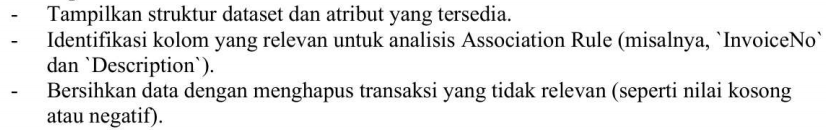

In [4]:
# struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# jumlah data kosong
print("Jumlah data kosong:")
print(df.isnull().sum())

# jumlah data negatif
print("\nJumlah data negatif:")

def hitung_negatif(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for cols in num_cols:
        neg_count = (df[cols] < 0).sum()
        print(f"{cols}: {neg_count}")
    
hitung_negatif(df)

Jumlah data kosong:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Jumlah data negatif:
Quantity: 10624
UnitPrice: 2
CustomerID: 0


In [11]:
# pembersihan data
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df.dropna(subset=['CustomerID'])

In [12]:
print("Jumlah data kosong sekarang:")
print(df.isna().sum())
print("\nJumlah data negatif sekarang:")
hitung_negatif(df)

Jumlah data kosong sekarang:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Jumlah data negatif sekarang:
Quantity: 0
UnitPrice: 0
CustomerID: 0


### 3. Persiapan Data untuk Association Rule


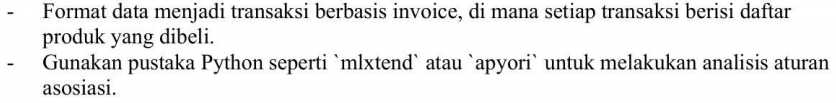

In [37]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, apriori

transaction_list = []

for invoice in df['InvoiceNo'].unique():
    item_list = list(
        set(df[df['InvoiceNo'] == invoice]['Description'])
    )
    
    if len(item_list) > 0:
        transaction_list.append(item_list)

te = TransactionEncoder()
te_array = te.fit(transaction_list).transform(transaction_list)
df2 = pd.DataFrame(te_array, columns=te.columns_)

### 4. Penerapan Algoritma


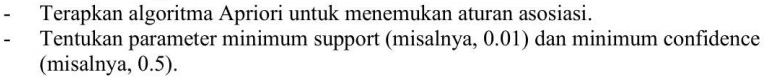

In [32]:
frequent_itemsets = apriori(df2, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

### 5. Evaluasi Aturan Asosiasi


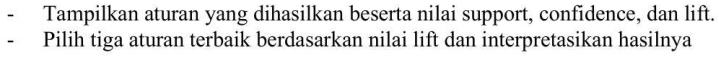

In [25]:
metrix = pd.DataFrame(rules)
metrix[['antecedents','consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)

,antecedents,consequents,support,confidence,lift
106,(REGENCY TEA PLATE GREEN ),(REGENCY TEA PLATE PINK),0.010900,0.748148,61.895899
107,(REGENCY TEA PLATE PINK),(REGENCY TEA PLATE GREEN ),0.010900,0.901786,61.895899
261,(POPPY'S PLAYHOUSE LIVINGROOM ),"(POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE ...",0.010037,0.738095,53.851894
256,"(POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE ...",(POPPY'S PLAYHOUSE LIVINGROOM ),0.010037,0.732283,53.851894
100,(REGENCY MILK JUG PINK ),(REGENCY SUGAR BOWL GREEN),0.011116,0.757353,52.370391
...,...,...,...,...,...
83,(PINK REGENCY TEACUP AND SAUCER),(REGENCY CAKESTAND 3 TIER),0.016674,0.555755,6.047715
98,(REGENCY TEAPOT ROSES ),(REGENCY CAKESTAND 3 TIER),0.010468,0.548023,5.963567
44,(GREEN REGENCY TEACUP AND SAUCER),(REGENCY CAKESTAND 3 TIER),0.020181,0.541245,5.889809
99,(ROSES REGENCY TEACUP AND SAUCER ),(REGENCY CAKESTAND 3 TIER),0.022664,0.536398,5.837074


In [36]:
# menampilkan 3 aturan asosiasi teratas berdasarkan nilai lift
top3result = metrix[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(3)
print(top3result.to_string())

                         antecedents                                              consequents   support  confidence       lift
106       (REGENCY TEA PLATE GREEN )                                 (REGENCY TEA PLATE PINK)  0.010900    0.748148  61.895899
107         (REGENCY TEA PLATE PINK)                               (REGENCY TEA PLATE GREEN )  0.010900    0.901786  61.895899
261  (POPPY'S PLAYHOUSE LIVINGROOM )  (POPPY'S PLAYHOUSE KITCHEN, POPPY'S PLAYHOUSE BEDROOM )  0.010037    0.738095  53.851894


Aturan terbaik berdasarkan lift menunjukkan bahwa produk yang berasal dari seri atau tema yang sama cenderung dibeli bersamaan. Aturan paling kuat adalah hubungan antara REGENCY TEA PLATE GREEN dan REGENCY TEA PLATE PINK, karena memiliki lift sangat tinggi yaitu 61,895899. Pelanggan yang membeli produk green memiliki kemungkinan membeli produk pink sekitar 61,9 kali lebih besar dibanding pembelian secara acak. Aturan sebaliknya, REGENCY TEA PLATE PINK dan REGENCY TEA PLATE GREEN, juga memiliki hubungan yang kuat dengan nilai lift yang mirip. Aturan ini bahkan lebih kuat dari sisi confidence, yaitu 90,18%. Hal ini memperkuat bahwa pelanggan yang membeli REGENCY TEA PLATE PINK hampir selalu juga membeli REGENCY TEA PLATE GREEN. Dengan demikian, kedua barang tersebut menjadi produk yang sangat potensial dalam sistem bundling atau rekomendasi belanja. 

Aturan lain yang juga memiliki hubungan yang kuat berdasarkan nilai lift adalah pembelian POPPY'S PLAYHOUSE LIVINGROOM dengan POPPY'S PLAYHOUSE KITCHEN dan POPPY'S PLAYHOUSE BEDROOM. Pelanggan yang membeli varian livingroom memiliki kemungkinan 53,8 kali untuk juga membeli varian kitchen dan bedroom. Hal ini juga diperkuat dengan nilai confidence sekitar 73,8%. Dengan demikian, pelanggan cenderung membeli beberapa produk dari seri yang sama sekaligus, misalnya ruang tamu, dapur, dan kamar tidur.

## Kesimpulan
Setelah melakukan praktikum ini mahasiswa diwajibkan untuk membuat kesimpulan. Kesimpulan dari percobaan ini merupakan bagian penting untuk merangkum temuan utama dan relevansinya dengan tujuan percobaan. Mahasiswa harus mampu menyimpulkan:
1. Apakah tujuan percobaan tercapai
2. Hubungan antara hasil percobaan dan dasar teori
3. Faktor-faktor yang mempengaruhi hasil percobaan, termasuk kemungkinan kesalahan yang terjadi

Berdasarkan percobaan yang dilakukan, tujuan percobaan sudah tercapai karena data berhasil diolah menjadi format transaksi berbasis invoice dan digunakan untuk membentuk aturan asosiasi menggunakan algoritma Apriori. Hasil percobaan juga sesuai dengan dasar teori association rule, yaitu menemukan pola keterkaitan antarproduk berdasarkan nilai support, confidence, dan lift. Misalnya, produk dalam seri yang sama, seperti REGENCY TEA PLATE GREEN dan REGENCY TEA PLATE PINK, memiliki nilai lift yang sangat tinggi. Hal ini menunjukkan hubungan pembelian yang kuat dan tidak terjadi secara acak. Hasil percobaan dipengaruhi oleh beberapa faktor, seperti pemilihan nilai minimum support dan confidence, kualitas data, banyaknya transaksi, serta proses pembersihan data. Kemungkinan kesalahan yang dapat terjadi antara lain pemilihan parameter yang terlalu rendah atau terlalu tinggi, item yang duplikat dalam satu invoice, penggunaan kolom produk yang kurang konsisten, serta data transaksi yang tidak lengkap sehingga dapat memengaruhi jumlah aturan yang terbentuk dan interpretasi hasil akhirnya.